# SAM 

`SAM prompting` vs `SAM + trainable head`

In [1]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [ ]:
import time

import sys
sys.path.append("/kaggle/input/datasets/rarescocosila/proiect-iava")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from segment_anything import SamPredictor, sam_model_registry

from pathlib import Path

from model_builders import build_sam_head_model, extract_trainable_head_parameters, mask_to_prompt_boxes, mask_to_prompt_points
import utils
from utils import (
    DiceBCELoss,
    SEED,
    benchmark_model,
    build_experiment_result_row,
    build_mask_from_record,
    build_optimization_profile,
    build_segmentation_dataloaders,
    collect_prediction_examples,
    count_trainable_parameters,
    create_optimizer,
    create_scaler,
    create_scheduler,
    device,
    dice_coefficient,
    fit_segmentation_model,
    get_protocol_splits,
    iou_score,
    load_image_as_rgb,
    load_segmentation_checkpoint,
    plot_training_history,
    prepare_model_for_optimizations,
    run_validation_epoch,
    seed_everything,
    summarize_protocol_splits,
    visualize_prediction_examples,
)

seed_everything(SEED)
print('Device:', device)

Device: cuda


In [3]:
BASE = Path("/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava")

utils.SEVERSTAL_ROOT = BASE / "severstal-steel-defect-detection"
utils.NEU_ROOT = BASE / "NEU-DET_data"
utils.KOLEKTOR_ROOT = BASE / "kolektor_data"

utils.TRAIN_DIR = f'{utils.SEVERSTAL_ROOT}/train_images'
utils.TRAIN_CSV = f'{utils.SEVERSTAL_ROOT}/train.csv'
utils.TEST_DIR = f'{utils.SEVERSTAL_ROOT}/test_images'

utils.build_severstal_metadata.__defaults__ = (
    utils.TRAIN_CSV,
    utils.TRAIN_DIR
)

build_severstal_metadata = utils.build_severstal_metadata

In [4]:
import urllib.request

url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
SAM_CHECKPOINT = "/kaggle/working/sam_vit_b_01ec64.pth"

urllib.request.urlretrieve(url, SAM_CHECKPOINT)

SAM_MODEL_TYPE = 'vit_b'
IMG_SIZE = 1024
BATCH_SIZE = 1
EPOCHS = 4
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 3
LOSS_NAME = 'dice_bce'
NORMALIZE = 'imagenet'
PROMPT_MODES = ['box', 'point']
PROMPT_EVAL_SAMPLES = 60
REFRESH_METADATA = True
SELECTED_SOURCES = ['severstal', 'neu', 'kolektor']

ACTIVE_PROFILE = build_optimization_profile(
    amp_mode='fp16',
    channels_last=False,
    compile_model=False,
    compile_mode='reduce-overhead',
    gradient_checkpointing=False,
    grad_accumulation_steps=2,
    max_grad_norm=1.0,
    ema_decay=0.999,
    persistent_workers=True,
    prefetch_factor=2,
)
ACTIVE_PROFILE

{'amp_mode': 'fp16',
 'channels_last': False,
 'compile_model': False,
 'compile_mode': 'reduce-overhead',
 'gradient_checkpointing': False,
 'grad_accumulation_steps': 2,
 'max_grad_norm': 1.0,
 'ema_decay': 0.999,
 'persistent_workers': True,
 'prefetch_factor': 2}

In [5]:
metadata, train_df, val_df, test_df = get_protocol_splits(random_state=SEED, refresh_cache=REFRESH_METADATA, cache_path="/kaggle/working/merged_metadata.csv")
train_df = train_df[train_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
val_df = val_df[val_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
test_df = test_df[test_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
display(summarize_protocol_splits(pd.concat([train_df, val_df, test_df], ignore_index=True)))

,protocol_split,source,images,defect_images,clean_images
0,train,kolektor,2097,221,1876
1,train,neu,863,863,0
2,train,severstal,10054,5333,4721
3,val,kolektor,234,25,209
4,val,neu,96,96,0
5,val,severstal,1257,666,591
6,test_final,kolektor,1004,110,894
7,test_final,neu,240,240,0
8,test_final,severstal,1257,667,590


In [6]:
train_dataset, val_dataset, train_loader, val_loader = build_segmentation_dataloaders(
    train_df=train_df,
    val_df=val_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=2,
    normalize=NORMALIZE,
    persistent_workers=ACTIVE_PROFILE['persistent_workers'],
    prefetch_factor=ACTIVE_PROFILE['prefetch_factor'],
)
test_dataset_with_meta = build_segmentation_dataloaders(
    train_df=train_df.head(8),
    val_df=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    normalize=NORMALIZE,
    return_metadata=True,
)[1]

In [ ]:
sam_head_model = build_sam_head_model(
    checkpoint_path=SAM_CHECKPOINT,
    model_type=SAM_MODEL_TYPE,
    freeze_image_encoder=True,
)
sam_head_model, opt_info = prepare_model_for_optimizations(
    sam_head_model,
    channels_last=ACTIVE_PROFILE['channels_last'],
    compile_model=ACTIVE_PROFILE['compile_model'],
    compile_mode=ACTIVE_PROFILE['compile_mode'],
    gradient_checkpointing=ACTIVE_PROFILE['gradient_checkpointing'],
)
criterion = DiceBCELoss() if LOSS_NAME == 'dice_bce' else None
optimizer = create_optimizer(extract_trainable_head_parameters(sam_head_model), name='adamw', lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = create_scheduler(optimizer, name='cosine', epochs=EPOCHS)
scaler = create_scaler(amp_mode=ACTIVE_PROFILE['amp_mode'])
trainable_params = count_trainable_parameters(sam_head_model)

/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1230: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return GradScaler()


sam_head train 1/4:   0%|          | 0/13014 [00:00<?, ?it/s]

/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1240: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)


sam_head val 1/4:   0%|          | 0/1587 [00:00<?, ?it/s]

sam_head epoch 1/4 | train_loss=0.1481 train_dice=0.8328 val_loss=0.1267 val_dice=0.8418 val_iou=0.8364


sam_head train 2/4:   0%|          | 0/13014 [00:00<?, ?it/s]

...

sam_head val 3/4:   0%|          | 0/1587 [00:00<?, ?it/s]

sam_head epoch 3/4 | train_loss=0.1236 train_dice=0.8420 val_loss=0.1510 val_dice=0.8072 val_iou=0.7971


sam_head train 4/4:   0%|          | 0/13014 [00:00<?, ?it/s]

sam_head val 4/4:   0%|          | 0/1587 [00:00<?, ?it/s]

sam_head epoch 4/4 | train_loss=0.1215 train_dice=0.8438 val_loss=0.1563 val_dice=0.7998 val_iou=0.7891
sam_head early stopping at epoch 4


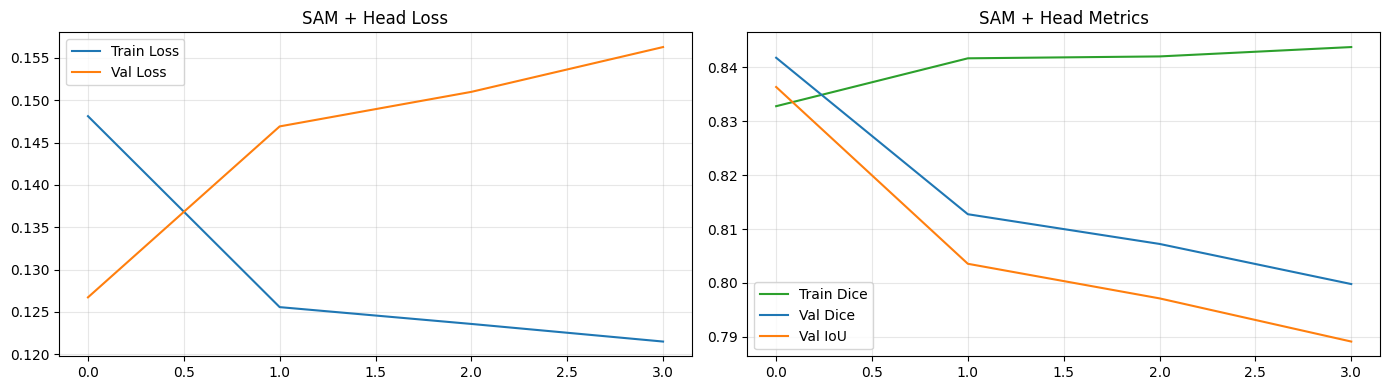

In [8]:
head_history = fit_segmentation_model(
    model=sam_head_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    scheduler=scheduler,
    scaler=scaler,
    patience=PATIENCE,
    checkpoint_path='sam_head_merged_best.pth',
    model_name='sam_head',
    amp_mode=ACTIVE_PROFILE['amp_mode'],
    grad_accumulation_steps=ACTIVE_PROFILE['grad_accumulation_steps'],
    max_grad_norm=ACTIVE_PROFILE['max_grad_norm'],
    use_channels_last=ACTIVE_PROFILE['channels_last'],
    ema_decay=ACTIVE_PROFILE['ema_decay'],
)
fig = plot_training_history(head_history, title_prefix='SAM + Head')
fig.savefig('sam_head_history.png', dpi=150)
plt.show()

In [9]:
load_segmentation_checkpoint(sam_head_model, 'sam_head_merged_best.pth', prefer_ema=True)
test_loader = build_segmentation_dataloaders(
    train_df=train_df.head(8),
    val_df=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    normalize=NORMALIZE,
)[3]
test_metrics = run_validation_epoch(
    model=sam_head_model,
    dataloader=test_loader,
    criterion=criterion,
    scaler=scaler,
    amp_mode=ACTIVE_PROFILE['amp_mode'],
    use_channels_last=ACTIVE_PROFILE['channels_last'],
)
test_metrics

val:   0%|          | 0/2501 [00:00<?, ?it/s]

/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1240: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)


{'loss': 0.10466189338921159,
 'dice': 0.8755418120122632,
 'iou': 0.8715795531410162}

In [10]:
head_benchmark = benchmark_model(sam_head_model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE), runs=10, warmup=3)
head_result = build_experiment_result_row(
    model_name='sam_head_merged',
    history=head_history,
    benchmark=head_benchmark,
    trainable_params=trainable_params,
    optimizer_name='adamw',
    scheduler_name='cosine',
    loss_name=LOSS_NAME,
    optimization_profile={**ACTIVE_PROFILE, **opt_info},
)
head_result.update({f'test_{key}': value for key, value in test_metrics.items()})
pd.DataFrame([head_result])

,model,epochs_ran,best_epoch,best_val_dice,best_val_iou,best_val_loss,final_train_loss,final_val_loss,optimizer,scheduler,...,opt_gradient_checkpointing,opt_grad_accumulation_steps,opt_max_grad_norm,opt_ema_decay,opt_persistent_workers,opt_prefetch_factor,opt_gradient_checkpointing_modules,test_loss,test_dice,test_iou
0,sam_head_merged,4,1,0.841775,0.836351,0.126716,0.121498,0.156269,adamw,cosine,...,False,2,1.0,0.999,True,2,[],0.104662,0.875542,0.87158


In [11]:
def evaluate_sam_prompting(test_records, checkpoint_path, model_type='vit_b', prompt_mode='box', max_samples=60):
    prompt_model = sam_model_registry[model_type](checkpoint=checkpoint_path).to(device)
    predictor = SamPredictor(prompt_model)
    sampled_df = test_records[test_records['has_defect']].sample(min(max_samples, int(test_records['has_defect'].sum())), random_state=SEED)
    dice_scores, iou_scores, latencies_ms = [], [], []
    for _, row in sampled_df.iterrows():
        record = row.to_dict()
        image = load_image_as_rgb(record['image_path'])
        true_mask = build_mask_from_record(record)
        pred_mask = np.zeros_like(true_mask)
        start = time.perf_counter()
        predictor.set_image(image)
        for class_idx in range(true_mask.shape[-1]):
            class_mask = true_mask[..., class_idx:class_idx + 1]
            if class_mask.sum() == 0:
                continue
            if prompt_mode == 'box':
                boxes = mask_to_prompt_boxes(class_mask, min_pixels=16)
                if not boxes:
                    continue
                masks, _, _ = predictor.predict(box=np.array(boxes[0], dtype=np.float32), multimask_output=False)
            else:
                points, labels = mask_to_prompt_points(class_mask, max_points=3)
                if len(points) == 0:
                    continue
                masks, _, _ = predictor.predict(point_coords=points, point_labels=labels, multimask_output=False)
            pred_mask[..., class_idx] = np.maximum(pred_mask[..., class_idx], masks[0].astype(np.uint8))
        latencies_ms.append((time.perf_counter() - start) * 1000.0)
        pred_tensor = torch.from_numpy(pred_mask).permute(2, 0, 1).unsqueeze(0).float()
        true_tensor = torch.from_numpy(true_mask).permute(2, 0, 1).unsqueeze(0).float()
        dice_scores.append(dice_coefficient(pred_tensor, true_tensor).item())
        iou_scores.append(iou_score(pred_tensor, true_tensor).item())
    return {
        'model': f'sam_prompt_{prompt_mode}',
        'samples': len(dice_scores),
        'best_val_dice': float(np.mean(dice_scores)) if dice_scores else 0.0,
        'best_val_iou': float(np.mean(iou_scores)) if iou_scores else 0.0,
        'test_dice': float(np.mean(dice_scores)) if dice_scores else 0.0,
        'test_iou': float(np.mean(iou_scores)) if iou_scores else 0.0,
        'mean_latency_ms': float(np.mean(latencies_ms)) if latencies_ms else 0.0,
        'std_latency_ms': float(np.std(latencies_ms)) if latencies_ms else 0.0,
        'throughput_img_s': float(1000.0 / np.mean(latencies_ms)) if latencies_ms else 0.0,
        'trainable_params': 0,
        'optimizer': 'none',
        'scheduler': 'none',
        'loss': 'prompt_inference',
    }

prompt_results = [evaluate_sam_prompting(test_df, SAM_CHECKPOINT, SAM_MODEL_TYPE, prompt_mode=mode, max_samples=PROMPT_EVAL_SAMPLES) for mode in PROMPT_MODES]
prompt_results_df = pd.DataFrame(prompt_results)
prompt_results_df

,model,samples,best_val_dice,best_val_iou,test_dice,test_iou,mean_latency_ms,std_latency_ms,throughput_img_s,trainable_params,optimizer,scheduler,loss
0,sam_prompt_box,60,0.902676,0.873636,0.902676,0.873636,484.618282,67.134711,2.063480,0,none,none,prompt_inference
1,sam_prompt_point,60,0.857731,0.830434,0.857731,0.830434,479.450158,34.765755,2.085723,0,none,none,prompt_inference


In [12]:
comparison_df = pd.concat([pd.DataFrame([head_result]), prompt_results_df], ignore_index=True, sort=False)
comparison_df.to_csv('sam_head_vs_prompt_results.csv', index=False)
comparison_df[['model', 'test_dice', 'test_iou', 'mean_latency_ms', 'throughput_img_s', 'trainable_params']]

,model,test_dice,test_iou,mean_latency_ms,throughput_img_s,trainable_params
0,sam_head_merged,0.875542,0.871580,479.799673,2.084203,4434036
1,sam_prompt_box,0.902676,0.873636,484.618282,2.063480,0
2,sam_prompt_point,0.857731,0.830434,479.450158,2.085723,0


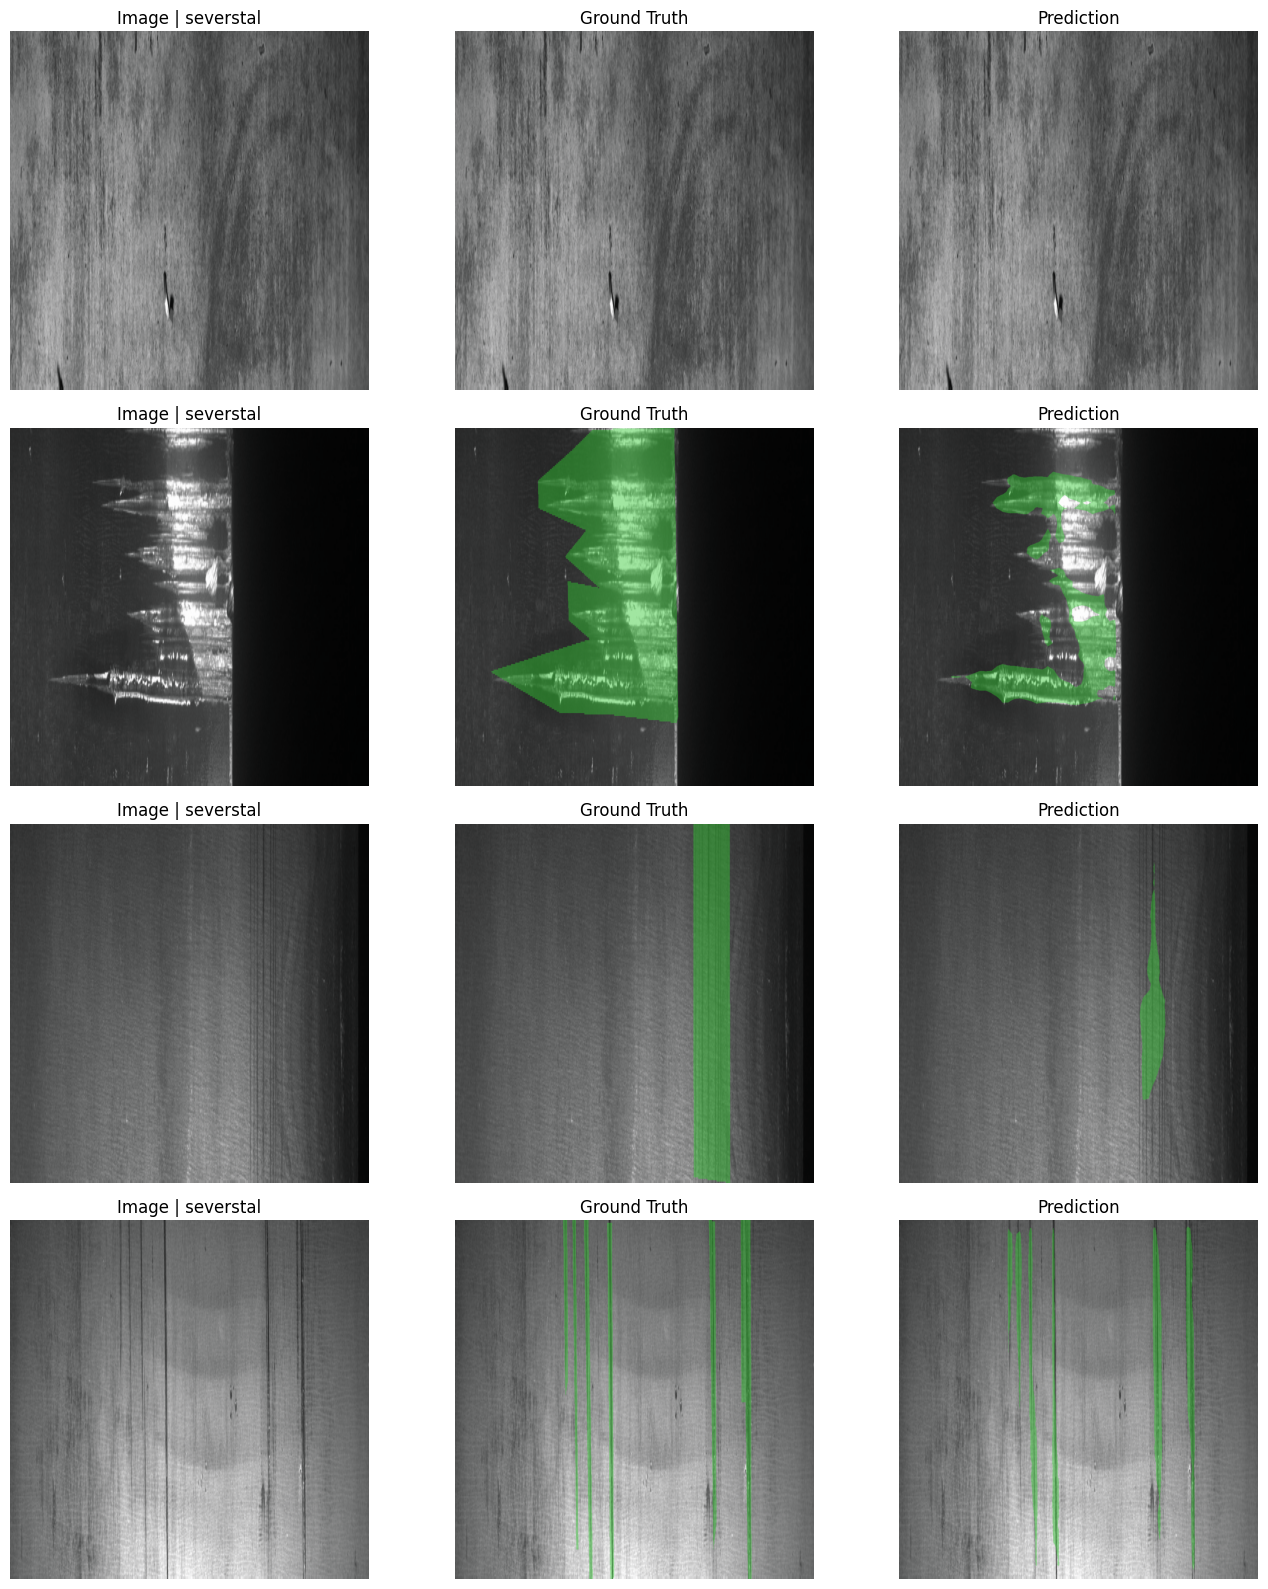

In [42]:
head_examples = collect_prediction_examples(sam_head_model, test_dataset_with_meta, num_samples=4, normalize=NORMALIZE)
fig = visualize_prediction_examples(head_examples, max_examples=4)
fig.savefig('sam_head_test_predictions.png', dpi=150)
plt.show()